<a href="https://colab.research.google.com/github/aleakucing/Pembelajaran-Memsin/blob/main/JS06/JS06_Assigment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [33]:
#Load Data
df = pd.read_csv('/content/drive/MyDrive/PemMes/JS6/voice.csv')

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [34]:
#Pra-pengolahan Data & Pemisahan Fitur
X = df.iloc[:, :-1].values
y = df['label'].values

encoder = LabelEncoder()
y = encoder.fit_transform(y)

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [35]:
# Konfigurasi split rasio dan kernel
split_ratios = {'70:30': 0.3, '80:20': 0.2}
kernels = ['linear', 'poly', 'rbf']

hasil_evaluasi = []

for split_name, test_size in split_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    for k in kernels:
        model = SVC(kernel=k)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        hasil_evaluasi.append({
            'Rasio Split': split_name,
            'Kernel': k,
            'Akurasi': f"{acc * 100:.2f}%"
        })

df_hasil = pd.DataFrame(hasil_evaluasi)
print(df_hasil)

  Rasio Split  Kernel Akurasi
0       70:30  linear  97.06%
1       70:30    poly  95.79%
2       70:30     rbf  98.11%
3       80:20  linear  97.63%
4       80:20    poly  97.16%
5       80:20     rbf  98.26%


**Soal 2: Klasifikasi Citra Siang & Malam dengan Fitur Histogram (Kernel RBF & Hyperparameter Tuning)**

In [36]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [45]:
DATA_PATH = Path('/content/drive/MyDrive/PemMes/JS6/images')

def load_dataset(base_dir):
    """Membaca seluruh citra day dan night dari folder training dan test"""
    base_dir = Path(base_dir)
    image_types = ['day', 'night']
    sub_dirs = ['training', 'test']
    image_list = []

    for sub in sub_dirs:
        for im_type in image_types:
            folder = base_dir / sub / im_type
            if folder.exists():
                for ext in ('*.jpg', '*.jpeg', '*.png'):
                    for file in folder.glob(ext):
                        im = cv2.imread(str(file))
                        if im is not None:
                            image_list.append((im, im_type))

    return image_list

# Load data citra
IMAGE_LIST = load_dataset(DATA_PATH)
print(f"Total gambar yang berhasil dimuat: {len(IMAGE_LIST)}")

Total gambar yang berhasil dimuat: 400


In [46]:
def standardize_input(image, width=600, height=400):
    """Menyamakan dimensi gambar"""
    return cv2.resize(image, (width, height))

def encode_label(label):
    """Encoding label: day=1, night=0"""
    return 1 if label == 'day' else 0

def extract_hsv_histogram(image, bins=32):
    """Ekstraksi fitur histogram kanal Value (kecerahan) HSV"""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [2], None, [bins], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

X_data = []
y_data = []

for img, label in IMAGE_LIST:
    img_std = standardize_input(img)
    feat = extract_hsv_histogram(img_std)

    X_data.append(feat)
    y_data.append(encode_label(label))

X_data = np.array(X_data)
y_data = np.array(y_data)

print(f"Bentuk X_data : {X_data.shape}")
print(f"Bentuk y_data : {y_data.shape}")

Bentuk X_data : (400, 32)
Bentuk y_data : (400,)


In [47]:
# Split data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

print(f"Jumlah data latih : {len(X_train)}")
print(f"Jumlah data uji   : {len(X_test)}")

Jumlah data latih : 320
Jumlah data uji   : 80


In [48]:
# Pipeline standardisasi fitur dan model SVC RBF
pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', random_state=42)
)

# Ruang parameter tuning
param_grid = {
    'svc__C': [0.1, 1, 10, 50, 100],
    'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# 5-fold cross validation
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Parameter Terbaik  : {grid.best_params_}")
print(f"Akurasi Terbaik CV : {grid.best_score_ * 100:.2f}%")

Parameter Terbaik  : {'svc__C': 10, 'svc__gamma': 'scale'}
Akurasi Terbaik CV : 99.06%


Akurasi Pengujian (80:20): 100.00%

Classification Report:
              precision    recall  f1-score   support

       night       1.00      1.00      1.00        40
         day       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



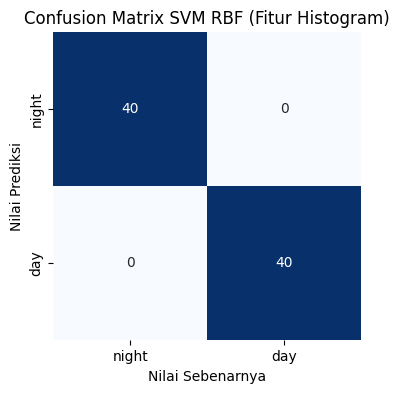

In [49]:
# Prediksi menggunakan parameter terbaik
model_terbaik = grid.best_estimator_
y_pred = model_terbaik.predict(X_test)

# Catat performansi akurasi
akurasi_test = accuracy_score(y_test, y_pred)
print(f"Akurasi Pengujian (80:20): {akurasi_test * 100:.2f}%\n")

# Laporan klasifikasi
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['night', 'day']))

# Visualisasi Confusion Matrix
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=['night', 'day'],
            yticklabels=['night', 'day'])
plt.xlabel('Nilai Sebenarnya')
plt.ylabel('Nilai Prediksi')
plt.title('Confusion Matrix SVM RBF (Fitur Histogram)')
plt.show()